In [ ]:
import numpy as np
import pandas as pd
import joblib
import os
import tensorflow as tf
import logging
from tensorflow.keras.models import load_model

tf.get_logger().setLevel('ERROR')
logging.getLogger('sklearn').setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

print("Loading Scalers and Models...")
scaler_X = joblib.load('models/scaler_X.pkl')
scaler_y = joblib.load('models/scaler_y.pkl')

lr_model = joblib.load('models/linear_regression_model.pkl')
rf_model = joblib.load('models/random_forest_model.pkl')
xgb_model = joblib.load('models/xgboost_model.pkl')
lstm_model = load_model('models/BiLSTM_model.h5', compile=False)
gru_model = load_model('models/GRU_model.h5', compile=False)
neurostack = joblib.load('models/NeuroStack_MetaLearner.pkl')

print("System Ready.\n")

def get_detailed_predictions(brand_encoded, month, year, usd_rate, lag_12_demand, recent_demand):

    expected_features = scaler_X.feature_names_in_

    input_data = {feat: 0.0 for feat in expected_features}
    
    for feat in expected_features:
        if 'Brand' in feat: 
            input_data[feat] = brand_encoded
        elif 'Year' in feat: 
            input_data[feat] = year
        elif 'Month' in feat and 'Sin' not in feat and 'Cos' not in feat: 
            input_data[feat] = month
        elif 'Month_Sin' in feat: 
            input_data[feat] = np.sin(2 * np.pi * month / 12)
        elif 'Month_Cos' in feat: 
            input_data[feat] = np.cos(2 * np.pi * month / 12)
        elif 'USD' in feat: 
            input_data[feat] = usd_rate
        elif 'Lag_12' in feat: 
            input_data[feat] = lag_12_demand
        elif 'Lag_1' in feat: 
            input_data[feat] = recent_demand 
        elif 'Lag' in feat: 
            input_data[feat] = recent_demand
        elif 'Rolling' in feat or 'Mean' in feat: 
            input_data[feat] = recent_demand

    input_df = pd.DataFrame([input_data])[expected_features]

    input_scaled = scaler_X.transform(input_df)

    p_lr_s = lr_model.predict(input_scaled).reshape(-1, 1)
    p_rf_s = rf_model.predict(input_scaled).reshape(-1, 1)
    p_xgb_s = xgb_model.predict(input_scaled).reshape(-1, 1)
    
    input_dl = input_scaled.reshape((1, 1, len(expected_features)))
    p_lstm_s = lstm_model.predict(input_dl, verbose=0).reshape(-1, 1)
    p_gru_s = gru_model.predict(input_dl, verbose=0).reshape(-1, 1)
    
    val_lr = np.expm1(scaler_y.inverse_transform(p_lr_s))[0][0]
    val_rf = np.expm1(scaler_y.inverse_transform(p_rf_s))[0][0]
    val_xgb = np.expm1(scaler_y.inverse_transform(p_xgb_s))[0][0]
    val_lstm = np.expm1(scaler_y.inverse_transform(p_lstm_s))[0][0]
    val_gru = np.expm1(scaler_y.inverse_transform(p_gru_s))[0][0]

    meta_input = pd.DataFrame({
        'LR': p_lr_s.ravel(), 
        'RF': p_rf_s.ravel(), 
        'XGB': p_xgb_s.ravel(), 
        'LSTM': p_lstm_s.ravel(), 
        'GRU': p_gru_s.ravel()
    })
    
    final_s = neurostack.predict(meta_input).reshape(-1, 1) 
    val_final = np.expm1(scaler_y.inverse_transform(final_s))[0][0]
    
    return {
        "LR": max(0, val_lr), 
        "RF": max(0, val_rf), 
        "XGB": max(0, val_xgb),
        "LSTM": max(0, val_lstm), 
        "GRU": max(0, val_gru), 
        "NeuroStack": max(0, val_final)
    }

TEST_BRAND = "Glustin"  
BRAND_CODE = 15       
MONTH = 3               
YEAR = 2026
CURRENT_USD = 310.50   
LAG_12_DEMAND = 450.0   
RECENT_DEMAND = 410.0 
STOCK_ON_HAND = 150     

results = get_detailed_predictions(BRAND_CODE, MONTH, YEAR, CURRENT_USD, LAG_12_DEMAND, RECENT_DEMAND)

suggested_order = max(0, results["NeuroStack"] - STOCK_ON_HAND)

print(f"RESULTS FOR: {TEST_BRAND} ({MONTH}/{YEAR})")
print("=" * 45)
for model_name, value in results.items():
    label = "🎯 FINAL" if model_name == "NeuroStack" else "   "
    print(f"{label} {model_name:<12} : {value:>10.2f}")
print("-" * 45)
print(f"PREDICTED DEMAND   : {results['NeuroStack']:.2f} Units")
print(f"CURRENT STOCK      : {STOCK_ON_HAND} Units")
print("-" * 45)
print(f"🛒 SUGGESTED ORDER QTY : {suggested_order:.2f} Units")
print("=" * 45)

Loading Scalers and Models...
System Ready.

RESULTS FOR: Glustin (3/2026)
    LR           :     351.11
    RF           :     414.02
    XGB          :     392.27
    LSTM         :     347.49
    GRU          :     415.62
🎯 FINAL NeuroStack   :     392.08
---------------------------------------------
PREDICTED DEMAND   : 392.08 Units
CURRENT STOCK      : 150 Units
---------------------------------------------
🛒 SUGGESTED ORDER QTY : 242.08 Units


In [ ]:
TEST_BRAND = "Metformin (Glilcomet)"  
BRAND_CODE = 0         
MONTH = 3               
YEAR = 2026
CURRENT_USD = 310.50   

LAG_12_DEMAND = 5271.0   

RECENT_DEMAND = 5100.0  

STOCK_ON_HAND = 1200 

results_metformin = get_detailed_predictions(BRAND_CODE, MONTH, YEAR, CURRENT_USD, LAG_12_DEMAND, RECENT_DEMAND)

suggested_order_met = max(0, results_metformin["NeuroStack"] - STOCK_ON_HAND)

print(f"RESULTS FOR: {TEST_BRAND} ({MONTH}/{YEAR})")
print("=" * 45)
for model_name, value in results_metformin.items():
    label = "🎯 FINAL" if model_name == "NeuroStack" else "   "
    print(f"{label} {model_name:<12} : {value:>10.2f}")
print("-" * 45)
print(f"PREDICTED DEMAND   : {results_metformin['NeuroStack']:.2f} Units")
print(f"CURRENT STOCK      : {STOCK_ON_HAND} Units")
print("-" * 45)
print(f"🛒 SUGGESTED ORDER QTY : {suggested_order_met:.2f} Units")
print("=" * 45)

RESULTS FOR: Metformin (Glilcomet) (3/2026)
    LR           :    3244.56
    RF           :    4948.17
    XGB          :    4368.81
    LSTM         :    5087.29
    GRU          :    4679.43
🎯 FINAL NeuroStack   :    4371.89
---------------------------------------------
PREDICTED DEMAND   : 4371.89 Units
CURRENT STOCK      : 1200 Units
---------------------------------------------
🛒 SUGGESTED ORDER QTY : 3171.89 Units


Generating 12-month forecast for Metformin (Glilcomet)...


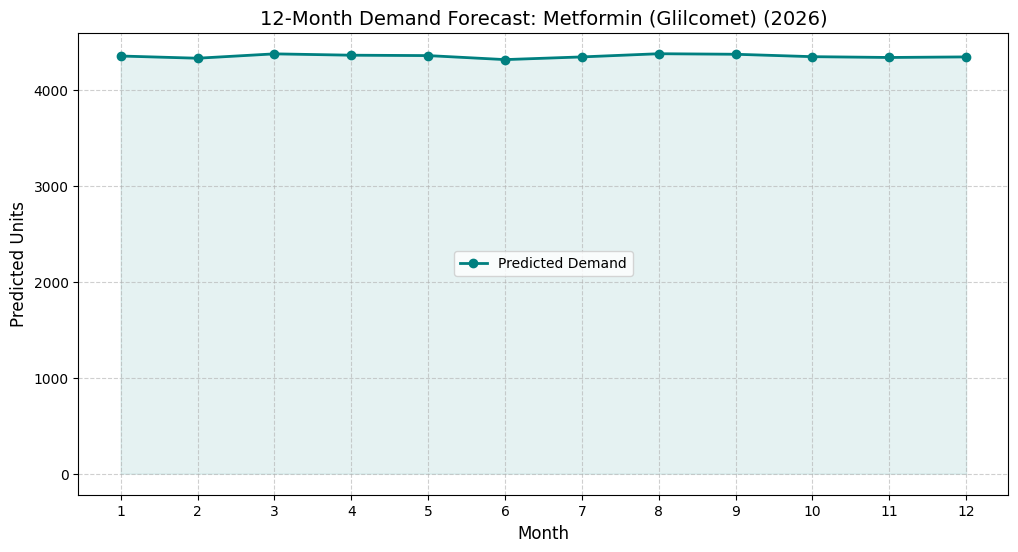

In [ ]:
import matplotlib.pyplot as plt

def plot_yearly_forecast(brand_code, brand_name, start_year, usd_rate, lag_12_base, recent_base):
    months = list(range(1, 13))
    forecasts = []
    
    print(f"Generating 12-month forecast for {brand_name}...")
    
    for m in months:

        res = get_detailed_predictions(brand_code, m, start_year, usd_rate, lag_12_base, recent_base)
        forecasts.append(res["NeuroStack"])

    plt.figure(figsize=(12, 6))
    plt.plot(months, forecasts, marker='o', linestyle='-', color='teal', linewidth=2, label='Predicted Demand')
    
    plt.fill_between(months, forecasts, alpha=0.1, color='teal') 
    plt.title(f"12-Month Demand Forecast: {brand_name} ({start_year})", fontsize=14)
    plt.xlabel("Month", fontsize=12)
    plt.ylabel("Predicted Units", fontsize=12)
    plt.xticks(months)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

plot_yearly_forecast(0, "Metformin (Glilcomet)", 2026, 310.50, 5271.0, 5100.0)